In [1]:
# Librerias
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers, optimizers, metrics
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image



from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [2]:
print("Dispositivo:", tf.test.gpu_device_name())

Dispositivo: /device:GPU:0


In [3]:
# Reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# Directorios
train_dir = "../data/lesions/train"
test_dir = "../data/lesions/test" 

In [5]:
color_train = "#5FAA3F"  
color_val = "#984bb7" 

# Importar y Redimensionar Máscaras

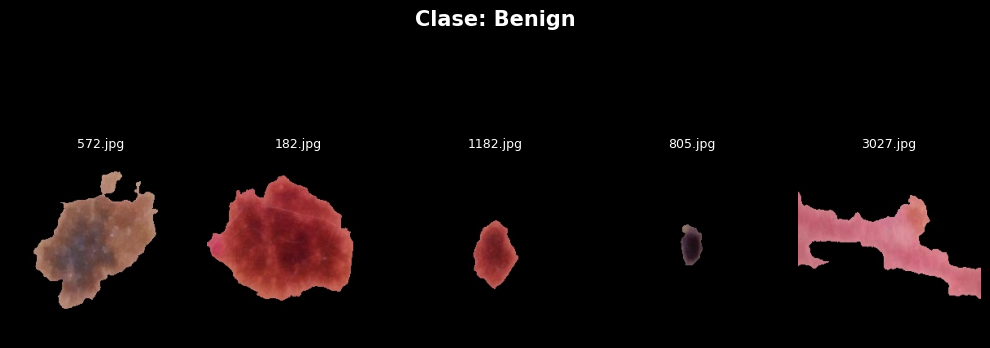

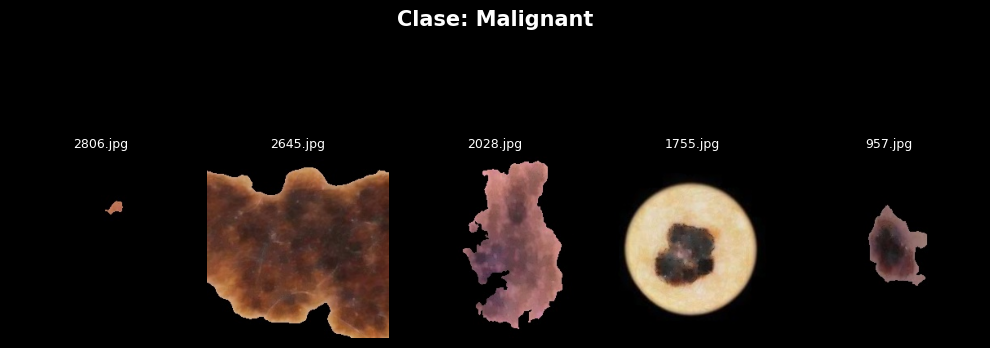

In [6]:
def mostrar_imagenes_random(carpeta, clase=None, n=5):
    if clase:
        carpeta = os.path.join(carpeta, clase)

    archivos = random.sample(os.listdir(carpeta), n)

    fig, axes = plt.subplots(1, n, figsize=(10, 4), facecolor='black')
    fig.suptitle(f"Clase: {clase}", fontsize=15, fontweight='bold', y=1.05, color='white')

    for ax, img_name in zip(axes, archivos):
        img = cv2.imread(os.path.join(carpeta, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(img_name, fontsize=9, color='white')
        ax.axis('off')
        ax.set_facecolor('black')  # fondo negro también para los ejes

    plt.subplots_adjust(top=0.8, wspace=0.05)  # red
    plt.tight_layout()
    plt.show()


# Ejemplo de uso
mostrar_imagenes_random(train_dir, "Benign", 5)
mostrar_imagenes_random(train_dir, "Malignant", 5)

### Normalización y Reescalado 

In [7]:
ROWS, COLS = 224, 224
BATCH= 32

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [9]:
train_gen = train_datagen.flow_from_directory(
    directory=train_dir,
    class_mode='categorical',      # 2 clases: Benign / Malignant
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=True,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    directory=test_dir,
    class_mode='categorical',
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=False,
    seed=SEED
)

Found 11879 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [10]:
print(train_gen.class_indices)

{'Benign': 0, 'Malignant': 1}


# Modelo

In [17]:
ROWS, COLS = 224, 224
input_shape = (ROWS, COLS, 3)

inputs = layers.Input(shape=input_shape)

# Bloque 1
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)

# Bloque 2
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)

# Bloque 3 (extra ligero)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)

# Clasificación
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(2, activation='softmax')(x)

In [ ]:
modelo5 = tf.keras.Model(inputs=inputs, outputs=outputs, name="HugeNet")

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [20]:
modelo5.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)

In [21]:
history_5= modelo5.fit(
    train_gen,
    validation_data=test_gen,
    epochs=40,
    callbacks=[early_stop] 
)

Epoch 1/40
372/372 [==============================] - 210s 52ms/step - loss: 0.6374 - accuracy: 0.6726 - precision: 0.6726 - recall: 0.6726 - val_loss: 0.6222 - val_accuracy: 0.6765 - val_precision: 0.6765 - val_recall: 0.6765
Epoch 2/40
372/372 [==============================] - 16s 44ms/step - loss: 0.5917 - accuracy: 0.7179 - precision: 0.7179 - recall: 0.7179 - val_loss: 0.5970 - val_accuracy: 0.7100 - val_precision: 0.7100 - val_recall: 0.7100
Epoch 3/40
372/372 [==============================] - 16s 44ms/step - loss: 0.5715 - accuracy: 0.7300 - precision: 0.7300 - recall: 0.7300 - val_loss: 0.5936 - val_accuracy: 0.7045 - val_precision: 0.7045 - val_recall: 0.7045
Epoch 4/40
372/372 [==============================] - 16s 44ms/step - loss: 0.5412 - accuracy: 0.7511 - precision: 0.7511 - recall: 0.7511 - val_loss: 0.5637 - val_accuracy: 0.7145 - val_precision: 0.7145 - val_recall: 0.7145
Epoch 5/40
372/372 [==============================] - 16s 44ms/step - loss: 0.5073 - accuracy: 

# Evaluación Modelo

## Curvas Train Vs Val

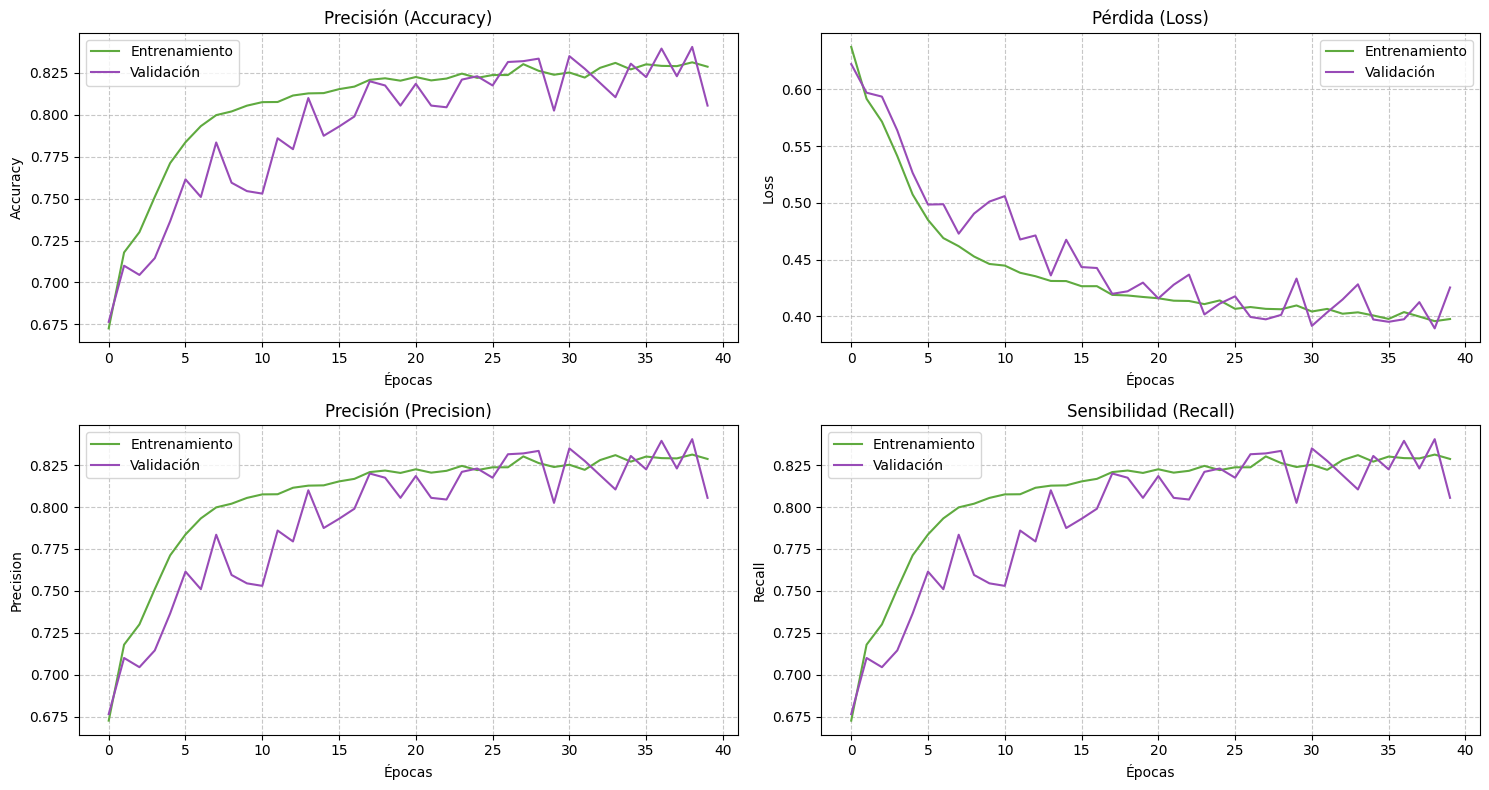

In [22]:
plt.figure(figsize=(15, 8))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history_5.history['accuracy'], color=color_train, label='Entrenamiento')
plt.plot(history_5.history['val_accuracy'], color=color_val, label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Loss
plt.subplot(2, 2, 2)
plt.plot(history_5.history['loss'], color=color_train, label='Entrenamiento')
plt.plot(history_5.history['val_loss'], color=color_val, label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Precision (si definiste precision en metrics del modelo)
plt.subplot(2, 2, 3)
plt.plot(history_5.history['precision'], color=color_train, label='Entrenamiento')
plt.plot(history_5.history['val_precision'], color=color_val, label='Validación')
plt.title('Precisión (Precision)')
plt.xlabel('Épocas')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Recall (si definiste recall en metrics del modelo)
plt.subplot(2, 2, 4)
plt.plot(history_5.history['recall'], color=color_train, label='Entrenamiento')
plt.plot(history_5.history['val_recall'], color=color_val, label='Validación')
plt.title('Sensibilidad (Recall)')
plt.xlabel('Épocas')
plt.ylabel('Recall')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Matriz de Confusión

In [23]:
y_pred_prob = modelo5.predict(test_gen)
y_true = test_gen.classes

63/63 [==============================] - 2s 28ms/step


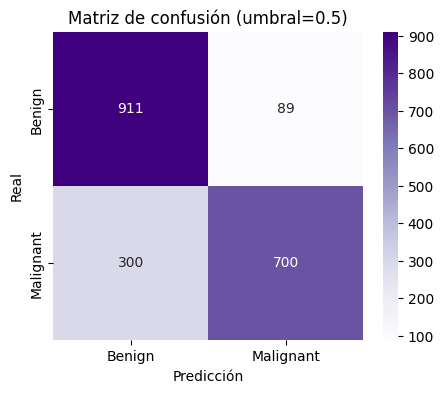

In [24]:
umbral = 0.5
y_pred_class = (y_pred_prob[:, 1] >= umbral).astype(int)

cm = confusion_matrix(y_true, y_pred_class)

labels = list(test_gen.class_indices.keys())
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f"Matriz de confusión (umbral={umbral})")
plt.show()

In [25]:
labels = list(test_gen.class_indices.keys())
print("Orden de clases:", test_gen.class_indices)

# Generar el reporte automático
print(classification_report(y_true, y_pred_class, target_names=labels, digits=3))

Orden de clases: {'Benign': 0, 'Malignant': 1}
              precision    recall  f1-score   support

      Benign      0.752     0.911     0.824      1000
   Malignant      0.887     0.700     0.783      1000

    accuracy                          0.805      2000
   macro avg      0.820     0.805     0.803      2000
weighted avg      0.820     0.805     0.803      2000



## Curva ROC

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)
print(f"AUC test: {roc_auc:.3f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color=color_val, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Conjunto Test (SimpleNet)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Imágenes Externas

In [26]:
external_dir = "../data/lesions/external"
ROWS, COLS = 224, 224
BATCH = 1  # una imagen por lote para visualizar fácilmente

ext_datagen = ImageDataGenerator(rescale=1./255)

ext_gen = ext_datagen.flow_from_directory(
    directory=external_dir,
    target_size=(ROWS, COLS),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

Found 45 images belonging to 2 classes.


In [27]:
# Probabilidades y clases
pred_probs = modelo5.predict(ext_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = ext_gen.classes
labels = list(ext_gen.class_indices.keys())

45/45 [==============================] - 0s 2ms/step


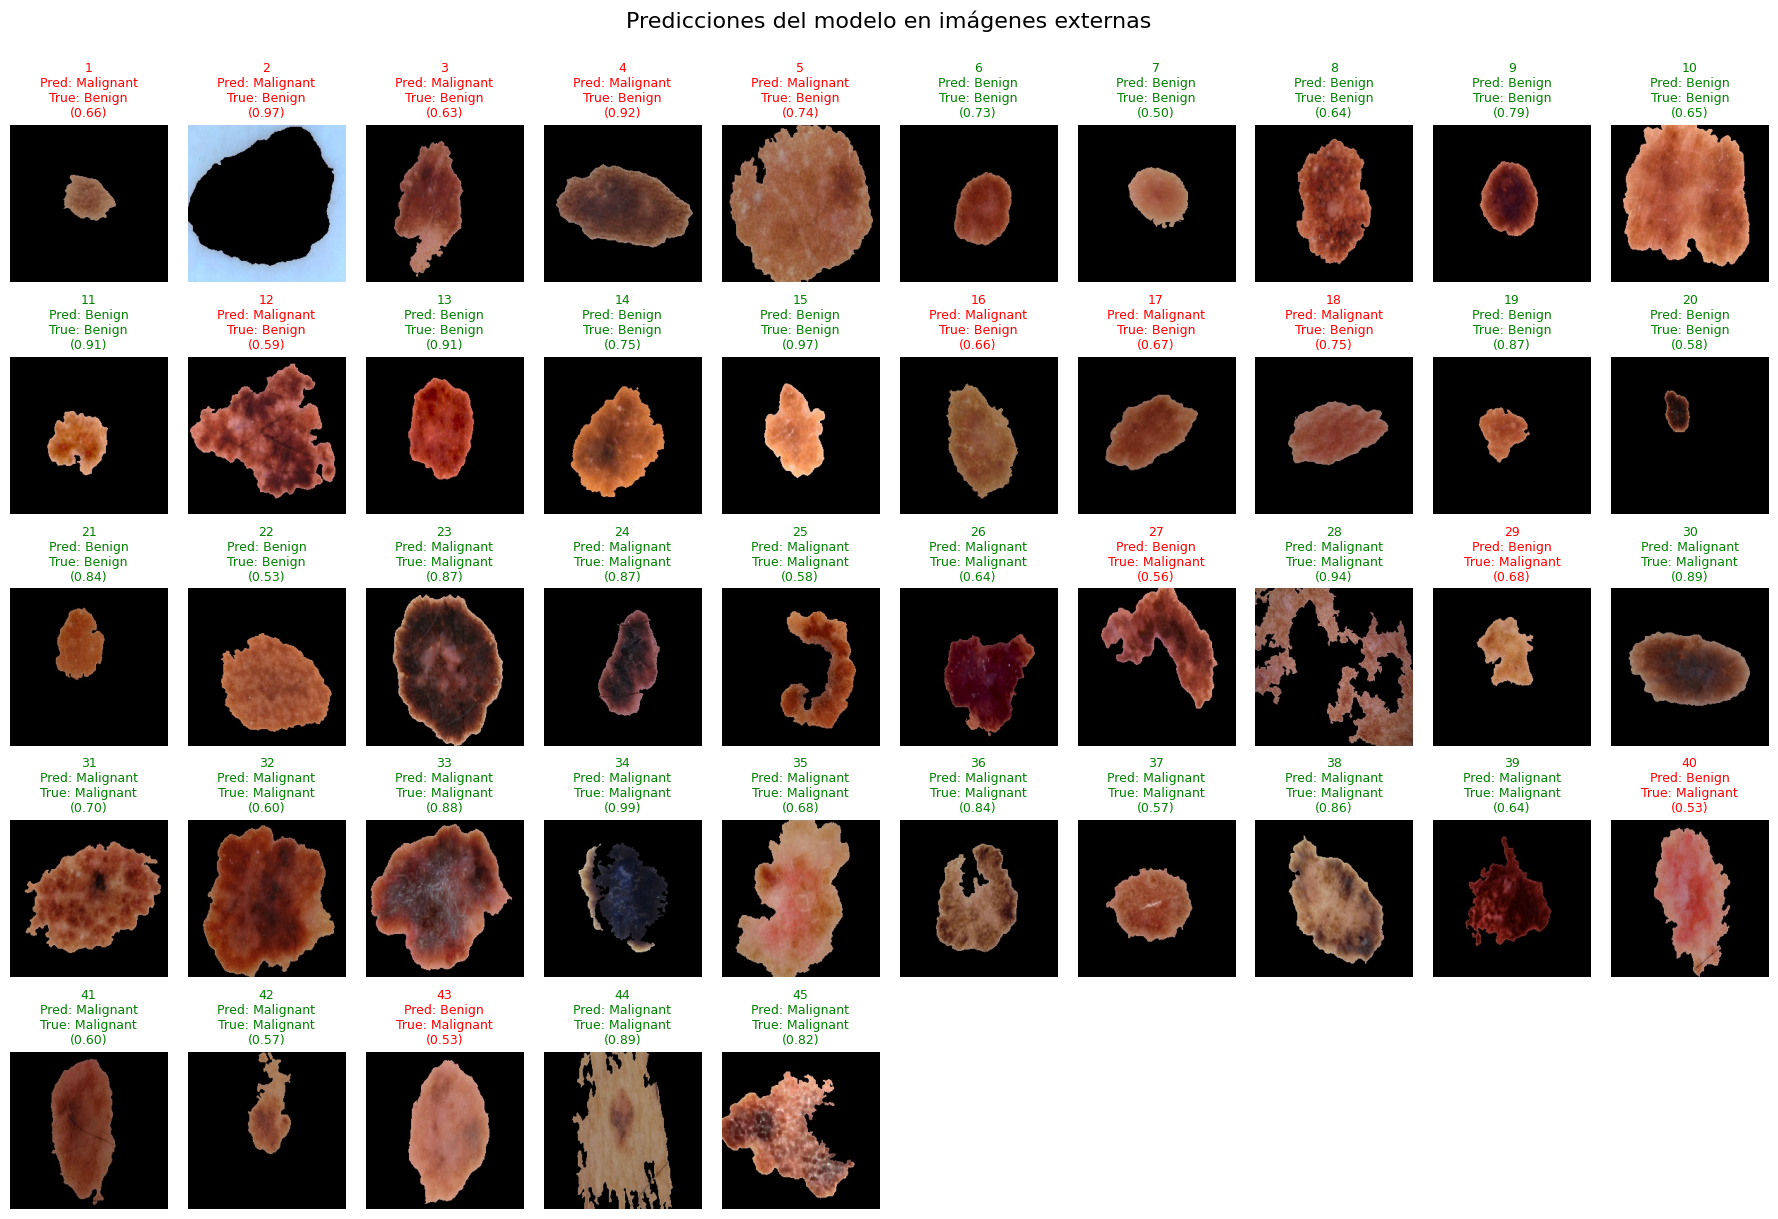

In [ ]:
N = 45  # o len(ext_gen.filenames) si quieres todas
rows, cols = 5, 10

plt.figure(figsize=(18, 12))

for i in range(N):
    img, _ = ext_gen[i]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img[0])

    true_label = labels[true_classes[i]]
    pred_label = labels[pred_classes[i]]
    prob = pred_probs[i][pred_classes[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"{i+1}\nPred: {pred_label}\nTrue: {true_label}\n({prob:.2f})", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout(pad=1.5)
plt.suptitle("Predicciones del modelo en imágenes externas", fontsize=16, y=1.03)
plt.show()

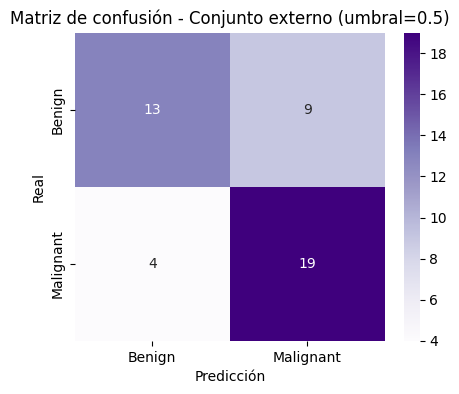

In [29]:
umbral = 0.5
y_pred_ext = (pred_probs[:, 1] >= umbral).astype(int)
y_true_ext = true_classes

# Calcular matriz de confusión
cm_ext = confusion_matrix(y_true_ext, y_pred_ext)

# Mostrar con seaborn
plt.figure(figsize=(5,4))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de confusión - Conjunto externo (umbral={umbral})")
plt.show()

# Procesamiento Modelo

In [31]:
modelo5.summary()

Model: "SimpleNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_6 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 56, 56, 128)       73

In [ ]:
modelo5.save("../models/simplenet.h5")